In [15]:
# Install required libraries
!pip install nltk rouge-score datasets

In [16]:
# Core libraries
import numpy as np
import tensorflow as tf
import random
import time
import os

# NLP libraries
import nltk
from nltk.translate.bleu_score import sentence_bleu, corpus_bleu, SmoothingFunction

# Visualization
import matplotlib.pyplot as plt

# Dataset (for Part 3)
from datasets import load_dataset

In [17]:
# Download tokenizer
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [18]:
# Fix randomness for reproducibility
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

In [19]:
print("TensorFlow version:", tf.__version__)

gpus = tf.config.list_physical_devices('GPU')
print("GPU available:", gpus)

if gpus:
    print("GPU is enabled 🚀")
else:
    print("Running on CPU ⚠️")

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU is enabled 🚀


In [20]:
print("All libraries installed and imported successfully ✅")

All libraries installed and imported successfully ✅


In [21]:
# Small English → German dataset (toy dataset)

english_sentences = [
    "i love you",
    "hello world",
    "how are you",
    "good morning",
    "thank you",
    "i am happy",
    "he is good",
    "she is sad",
    "they are here",
    "i am learning"
]

german_sentences = [
    "ich liebe dich",
    "hallo welt",
    "wie geht es dir",
    "guten morgen",
    "danke schoen",
    "ich bin gluecklich",
    "er ist gut",
    "sie ist traurig",
    "sie sind hier",
    "ich lerne"
]

print("Dataset loaded successfully ✅")
print("Total sentence pairs:", len(english_sentences))

Dataset loaded successfully ✅
Total sentence pairs: 10


In [22]:
# Display sample pairs

for i in range(5):
    print(f"{i+1}. EN: {english_sentences[i]}  →  DE: {german_sentences[i]}")

1. EN: i love you  →  DE: ich liebe dich
2. EN: hello world  →  DE: hallo welt
3. EN: how are you  →  DE: wie geht es dir
4. EN: good morning  →  DE: guten morgen
5. EN: thank you  →  DE: danke schoen


In [23]:
# Simple lowercase cleaning

def clean_text(sentence):
    return sentence.lower().strip()

english_sentences = [clean_text(s) for s in english_sentences]
german_sentences = [clean_text(s) for s in german_sentences]

print("Text cleaned successfully ✅")

Text cleaned successfully ✅


In [24]:
# Analyze sentence lengths

max_len_en = max(len(s.split()) for s in english_sentences)
max_len_de = max(len(s.split()) for s in german_sentences)

print("Max English length:", max_len_en)
print("Max German length:", max_len_de)

Max English length: 3
Max German length: 4


In [26]:
# Special tokens
PAD = 0
SOS = 1
EOS = 2
UNK = 3

class Vocabulary:
    def __init__(self):
        self.word2idx = {
            "<pad>": PAD,
            "<sos>": SOS,
            "<eos>": EOS,
            "<unk>": UNK
        }
        self.idx2word = {
            PAD: "<pad>",
            SOS: "<sos>",
            EOS: "<eos>",
            UNK: "<unk>"
        }
        self.count = 4  # starting index

    def add_sentence(self, sentence):
        for word in sentence.split():
            self.add_word(word)

    def add_word(self, word):
        if word not in self.word2idx:
            self.word2idx[word] = self.count
            self.idx2word[self.count] = word
            self.count += 1

    def __len__(self):
        return self.count

In [27]:
# Create vocab objects
src_vocab = Vocabulary()
tgt_vocab = Vocabulary()

# Add sentences to vocab
for sentence in english_sentences:
    src_vocab.add_sentence(sentence)

for sentence in german_sentences:
    tgt_vocab.add_sentence(sentence)

print("Source Vocabulary Size:", len(src_vocab))
print("Target Vocabulary Size:", len(tgt_vocab))

Source Vocabulary Size: 23
Target Vocabulary Size: 27


In [28]:
# Show some word mappings

print("\nSample word mappings (English):")
for word, idx in list(src_vocab.word2idx.items())[:10]:
    print(f"{word} → {idx}")

print("\nSample word mappings (German):")
for word, idx in list(tgt_vocab.word2idx.items())[:10]:
    print(f"{word} → {idx}")


Sample word mappings (English):
<pad> → 0
<sos> → 1
<eos> → 2
<unk> → 3
i → 4
love → 5
you → 6
hello → 7
world → 8
how → 9

Sample word mappings (German):
<pad> → 0
<sos> → 1
<eos> → 2
<unk> → 3
ich → 4
liebe → 5
dich → 6
hallo → 7
welt → 8
wie → 9


In [29]:
# Convert sentence to indices

def encode_sentence(sentence, vocab):
    return [vocab.word2idx.get(word, UNK) for word in sentence.split()]

# Example
print("Sample Encoding:")
print("Sentence:", english_sentences[0])
print("Encoded:", encode_sentence(english_sentences[0], src_vocab))

Sample Encoding:
Sentence: i love you
Encoded: [4, 5, 6]


In [30]:
# Add <sos> and <eos>

def add_tokens(sequence):
    return [SOS] + sequence + [EOS]

# Example
sample = encode_sentence(english_sentences[0], src_vocab)
print("With tokens:", add_tokens(sample))

With tokens: [1, 4, 5, 6, 2]


In [31]:
# Pad sequences to fixed length

def pad_sequence(seq, max_len):
    return seq + [PAD] * (max_len - len(seq))

In [32]:
MAX_LEN = 10

encoder_inputs = []
decoder_inputs = []
decoder_targets = []

for src, tgt in zip(english_sentences, german_sentences):

    # Encode
    src_seq = encode_sentence(src, src_vocab)
    tgt_seq = encode_sentence(tgt, tgt_vocab)

    # Add tokens
    src_seq = add_tokens(src_seq)
    tgt_seq = add_tokens(tgt_seq)

    # Prepare decoder input and target
    dec_input = tgt_seq[:-1]   # remove last
    dec_target = tgt_seq[1:]   # remove first

    # Pad
    encoder_inputs.append(pad_sequence(src_seq, MAX_LEN))
    decoder_inputs.append(pad_sequence(dec_input, MAX_LEN))
    decoder_targets.append(pad_sequence(dec_target, MAX_LEN))

# Convert to numpy
import numpy as np

encoder_inputs = np.array(encoder_inputs)
decoder_inputs = np.array(decoder_inputs)
decoder_targets = np.array(decoder_targets)

print("Shapes:")
print("Encoder:", encoder_inputs.shape)
print("Decoder Input:", decoder_inputs.shape)
print("Decoder Target:", decoder_targets.shape)

Shapes:
Encoder: (10, 10)
Decoder Input: (10, 10)
Decoder Target: (10, 10)


In [33]:
# Show one sample

print("Original:", english_sentences[0])
print("Encoded:", encoder_inputs[0])

print("\nDecoder Input:", decoder_inputs[0])
print("Decoder Target:", decoder_targets[0])

Original: i love you
Encoded: [1 4 5 6 2 0 0 0 0 0]

Decoder Input: [1 4 5 6 0 0 0 0 0 0]
Decoder Target: [4 5 6 2 0 0 0 0 0 0]


In [34]:
class Encoder(tf.keras.layers.Layer):
    def __init__(self, vocab_size, embedding_dim=64, hidden_dim=128):
        super().__init__()

        # Embedding layer: converts word indices → dense vectors
        self.embedding = tf.keras.layers.Embedding(vocab_size, embedding_dim)

        # Bidirectional LSTM
        self.bilstm = tf.keras.layers.Bidirectional(
            tf.keras.layers.LSTM(hidden_dim,
                                 return_sequences=True,
                                 return_state=True)
        )

        # Dense layer to reduce dimension (important!)
        self.fc = tf.keras.layers.Dense(hidden_dim)

    def call(self, x):
        # x shape: (batch_size, seq_len)

        x = self.embedding(x)
        # shape: (batch, seq_len, embedding_dim)

        outputs, forward_h, forward_c, backward_h, backward_c = self.bilstm(x)

        # Concatenate forward & backward states
        hidden = tf.concat([forward_h, backward_h], axis=-1)
        cell = tf.concat([forward_c, backward_c], axis=-1)

        # Reduce dimension to match decoder
        hidden = self.fc(hidden)
        cell = self.fc(cell)

        return outputs, hidden, cell

In [35]:
# Create encoder instance
encoder = Encoder(vocab_size=len(src_vocab.word2idx))

print("Encoder initialized successfully ✅")

Encoder initialized successfully ✅


In [36]:
# Test with sample input

sample_input = encoder_inputs[:2]  # batch of 2

outputs, hidden, cell = encoder(sample_input)

print("Encoder Output Shape:", outputs.shape)
print("Hidden Shape:", hidden.shape)
print("Cell Shape:", cell.shape)

Encoder Output Shape: (2, 10, 256)
Hidden Shape: (2, 128)
Cell Shape: (2, 128)


In [37]:
class LuongAttention(tf.keras.layers.Layer):
    def __init__(self, hidden_dim):
        super().__init__()

        # Linear layer to transform encoder outputs
        self.W = tf.keras.layers.Dense(hidden_dim)

    def call(self, decoder_hidden, encoder_outputs):
        """
        decoder_hidden: (batch, hidden_dim)
        encoder_outputs: (batch, seq_len, hidden_dim)
        """

        # Expand decoder hidden → (batch, 1, hidden)
        decoder_hidden = tf.expand_dims(decoder_hidden, 1)

        # Compute score
        score = tf.reduce_sum(
            self.W(encoder_outputs) * decoder_hidden,
            axis=2
        )  # (batch, seq_len)

        # Convert to probabilities
        attention_weights = tf.nn.softmax(score, axis=1)

        # Compute context vector
        context_vector = tf.reduce_sum(
            encoder_outputs * tf.expand_dims(attention_weights, 2),
            axis=1
        )  # (batch, hidden_dim)

        return context_vector, attention_weights

In [38]:
attention = LuongAttention(hidden_dim=128)

print("Attention initialized ✅")

Attention initialized ✅


In [39]:
# Use encoder output from previous section

context, weights = attention(hidden, outputs)

print("Context Shape:", context.shape)
print("Attention Weights Shape:", weights.shape)

Context Shape: (2, 256)
Attention Weights Shape: (2, 10)


In [40]:
print("Sum of weights (should be ~1):")
print(tf.reduce_sum(weights[0]))

Sum of weights (should be ~1):
tf.Tensor(1.0, shape=(), dtype=float32)


In [41]:
class Decoder(tf.keras.layers.Layer):
    def __init__(self, vocab_size, embedding_dim=64, hidden_dim=128):
        super().__init__()

        # Embedding layer
        self.embedding = tf.keras.layers.Embedding(vocab_size, embedding_dim)

        # LSTM Cell (step-by-step decoding)
        self.lstm = tf.keras.layers.LSTMCell(hidden_dim)

        # Attention layer
        self.attention = LuongAttention(hidden_dim)

        # Final output layer
        self.fc = tf.keras.layers.Dense(vocab_size)

    def call(self, decoder_inputs, hidden, cell, encoder_outputs):
        """
        decoder_inputs: (batch, seq_len)
        hidden, cell: (batch, hidden)
        encoder_outputs: (batch, seq_len, hidden)
        """

        outputs = []

        # Loop over each time step
        for t in range(decoder_inputs.shape[1]):

            # Get word at time step t
            x = self.embedding(decoder_inputs[:, t])   # (batch, embedding)

            # LSTM step
            hidden, [hidden, cell] = self.lstm(x, [hidden, cell])

            # Apply attention
            context_vector, attention_weights = self.attention(hidden, encoder_outputs)

            # Combine hidden + context
            combined = tf.concat([hidden, context_vector], axis=-1)

            # Predict next word
            output = self.fc(combined)

            outputs.append(output)

        # Stack outputs → (batch, seq_len, vocab_size)
        outputs = tf.stack(outputs, axis=1)

        return outputs

In [42]:
decoder = Decoder(vocab_size=len(tgt_vocab.word2idx))

print("Decoder initialized successfully ✅")

Decoder initialized successfully ✅


In [43]:
# Test with encoder output

sample_input = encoder_inputs[:2]

enc_outputs, hidden, cell = encoder(sample_input)

dec_out = decoder(decoder_inputs[:2], hidden, cell, enc_outputs)

print("Decoder Output Shape:", dec_out.shape)

Decoder Output Shape: (2, 10, 27)


In [44]:
class Seq2Seq(tf.keras.Model):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def call(self, encoder_inputs, decoder_inputs):
        """
        encoder_inputs: (batch, seq_len)
        decoder_inputs: (batch, seq_len)
        """

        # Step 1: Pass through encoder
        encoder_outputs, hidden, cell = self.encoder(encoder_inputs)

        # Step 2: Pass through decoder (with attention)
        decoder_outputs = self.decoder(
            decoder_inputs,
            hidden,
            cell,
            encoder_outputs
        )

        return decoder_outputs

In [45]:
model = Seq2Seq(encoder, decoder)

print("Full Model Created Successfully ✅")

Full Model Created Successfully ✅


In [46]:
# Test forward pass

sample_enc = encoder_inputs[:2]
sample_dec = decoder_inputs[:2]

outputs = model(sample_enc, sample_dec)

print("Model Output Shape:", outputs.shape)

Model Output Shape: (2, 10, 27)


In [47]:
class Seq2Seq_NoAttention(tf.keras.Model):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def call(self, encoder_inputs, decoder_inputs):
        encoder_outputs, hidden, cell = self.encoder(encoder_inputs)

        # ❌ No attention used
        outputs = []

        for t in range(decoder_inputs.shape[1]):
            x = decoder.embedding(decoder_inputs[:, t])
            hidden, [hidden, cell] = decoder.lstm(x, [hidden, cell])
            out = decoder.fc(hidden)
            outputs.append(out)

        return tf.stack(outputs, axis=1)

In [48]:
# Loss function
loss_function = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

In [49]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

In [50]:
@tf.function
def train_step(enc_inp, dec_inp, dec_tar):

    with tf.GradientTape() as tape:
        predictions = model(enc_inp, dec_inp)

        loss = loss_function(dec_tar, predictions)

    gradients = tape.gradient(loss, model.trainable_variables)

    optimizer.apply_gradients(zip(gradients, model.trainable_variables))

    return loss

In [51]:
EPOCHS = 50

loss_history = []

start_time = time.time()

for epoch in range(EPOCHS):

    loss = train_step(encoder_inputs, decoder_inputs, decoder_targets)

    loss_history.append(loss.numpy())

    if epoch % 10 == 0:
        print(f"Epoch {epoch} | Loss: {loss.numpy():.4f}")

end_time = time.time()

training_time = end_time - start_time

print("\nTraining Completed ✅")
print("Total Training Time:", training_time, "seconds")

Epoch 0 | Loss: 3.2909
Epoch 10 | Loss: 1.7047
Epoch 20 | Loss: 1.3485
Epoch 30 | Loss: 1.1533
Epoch 40 | Loss: 1.0461

Training Completed ✅
Total Training Time: 8.017969369888306 seconds


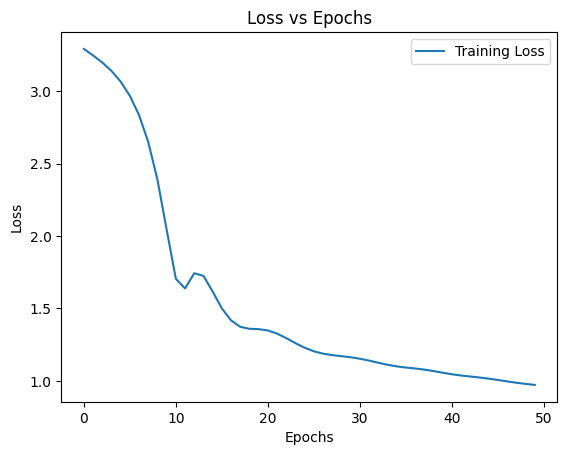

In [52]:
import matplotlib.pyplot as plt

plt.plot(loss_history, label="Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss vs Epochs")
plt.legend()
plt.show()

In [54]:
class Decoder_NoAttention(tf.keras.layers.Layer):
    def __init__(self, vocab_size, embedding_dim=64, hidden_dim=128):
        super().__init__()

        self.embedding = tf.keras.layers.Embedding(vocab_size, embedding_dim)
        self.lstm = tf.keras.layers.LSTMCell(hidden_dim)

        # ⚠️ IMPORTANT: input = hidden only (NOT hidden+context)
        self.fc = tf.keras.layers.Dense(vocab_size)

    def call(self, decoder_inputs, hidden, cell):
        outputs = []

        for t in range(decoder_inputs.shape[1]):
            x = self.embedding(decoder_inputs[:, t])

            hidden, [hidden, cell] = self.lstm(x, [hidden, cell])

            # ONLY hidden (correct)
            out = self.fc(hidden)

            outputs.append(out)

        return tf.stack(outputs, axis=1)

In [55]:
class Seq2Seq_NoAttention(tf.keras.Model):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def call(self, encoder_inputs, decoder_inputs):
        encoder_outputs, hidden, cell = self.encoder(encoder_inputs)

        # ⚠️ No attention → ignore encoder_outputs
        outputs = self.decoder(decoder_inputs, hidden, cell)

        return outputs

In [56]:
decoder_no_attn = Decoder_NoAttention(vocab_size=len(tgt_vocab.word2idx))

model_no_attn = Seq2Seq_NoAttention(encoder, decoder_no_attn)

In [57]:
optimizer2 = tf.keras.optimizers.Adam()

loss_no_attn = []

for epoch in range(EPOCHS):

    with tf.GradientTape() as tape:
        preds = model_no_attn(encoder_inputs, decoder_inputs)
        loss = loss_function(decoder_targets, preds)

    grads = tape.gradient(loss, model_no_attn.trainable_variables)
    optimizer2.apply_gradients(zip(grads, model_no_attn.trainable_variables))

    loss_no_attn.append(loss.numpy())

    if epoch % 10 == 0:
        print(f"[No Attn] Epoch {epoch} | Loss: {loss.numpy():.4f}")

[No Attn] Epoch 0 | Loss: 3.2585
[No Attn] Epoch 10 | Loss: 1.2695
[No Attn] Epoch 20 | Loss: 1.0323
[No Attn] Epoch 30 | Loss: 0.9180
[No Attn] Epoch 40 | Loss: 0.8302


In [59]:
def predict_sentence(model, sentence):

    # Encode input sentence
    seq = encode_sentence(sentence, src_vocab)
    seq = [SOS] + seq + [EOS]

    # Pad input
    seq = seq + [PAD] * (10 - len(seq))
    seq = np.array([seq])

    # Encoder forward pass
    encoder_outputs, hidden, cell = model.encoder(seq)

    # Start with <sos>
    dec_input = np.array([[SOS]])

    result = []

    for _ in range(10):

        preds = model.decoder(dec_input, hidden, cell, encoder_outputs)

        # Get predicted word
        pred_id = tf.argmax(preds[0, 0]).numpy()

        if pred_id == EOS:
            break

        result.append(tgt_vocab.idx2word.get(pred_id, "<unk>"))

        # Next input
        dec_input = np.array([[pred_id]])

    return " ".join(result)

In [60]:
print("Input:", "i love you")
print("Prediction:", predict_sentence(model, "i love you"))

Input: i love you
Prediction: ich ich ich ich ich ich ich ich ich ich


In [61]:
test_sentences = [
    "i love you",
    "good morning",
    "thank you"
]

for sent in test_sentences:
    print("\nInput:", sent)
    print("Prediction:", predict_sentence(model, sent))


Input: i love you
Prediction: ich ich ich ich ich ich ich ich ich ich

Input: good morning
Prediction: ich ich ich ich ich ich ich ich ich ich

Input: thank you
Prediction: ich ich ich ich ich ich ich ich ich ich


In [62]:
def calculate_bleu(reference, prediction):
    smoothie = SmoothingFunction().method4
    return sentence_bleu([reference.split()], prediction.split(), smoothing_function=smoothie)

In [63]:
bleu_scores = []

for src, tgt in zip(english_sentences, german_sentences):
    pred = predict_sentence(model, src)

    score = calculate_bleu(tgt, pred)
    bleu_scores.append(score)

    print(f"\nInput: {src}")
    print(f"Target: {tgt}")
    print(f"Predicted: {pred}")
    print(f"BLEU: {score:.4f}")


Input: i love you
Target: ich liebe dich
Predicted: ich ich ich ich ich ich ich ich ich ich
BLEU: 0.0235

Input: hello world
Target: hallo welt
Predicted: ich ich ich ich ich ich ich ich ich ich
BLEU: 0.0000

Input: how are you
Target: wie geht es dir
Predicted: ich ich ich ich ich ich ich ich ich ich
BLEU: 0.0000

Input: good morning
Target: guten morgen
Predicted: ich ich ich ich ich ich ich ich ich ich
BLEU: 0.0000

Input: thank you
Target: danke schoen
Predicted: ich ich ich ich ich ich ich ich ich ich
BLEU: 0.0000

Input: i am happy
Target: ich bin gluecklich
Predicted: ich ich ich ich ich ich ich ich ich ich
BLEU: 0.0235

Input: he is good
Target: er ist gut
Predicted: ich ich ich ich ich ich ich ich ich ich
BLEU: 0.0000

Input: she is sad
Target: sie ist traurig
Predicted: ich ich ich ich ich ich ich ich ich ich
BLEU: 0.0000

Input: they are here
Target: sie sind hier
Predicted: ich ich ich ich ich ich ich ich ich ich
BLEU: 0.0000

Input: i am learning
Target: ich lerne
Predict

In [64]:
avg_bleu = np.mean(bleu_scores)

print("\nAverage BLEU Score:", avg_bleu)


Average BLEU Score: 0.007037248552467306


In [66]:
def predict_sentence_attn(model, sentence):

    seq = encode_sentence(sentence, src_vocab)
    seq = [SOS] + seq + [EOS]
    seq = seq + [PAD] * (10 - len(seq))
    seq = np.array([seq])

    encoder_outputs, hidden, cell = model.encoder(seq)

    dec_input = np.array([[SOS]])
    result = []

    for _ in range(10):
        preds = model.decoder(dec_input, hidden, cell, encoder_outputs)

        pred_id = tf.argmax(preds[0, 0]).numpy()

        if pred_id == EOS:
            break

        result.append(tgt_vocab.idx2word.get(pred_id, "<unk>"))
        dec_input = np.array([[pred_id]])

    return " ".join(result)

In [67]:
def predict_sentence_no_attn(model, sentence):

    seq = encode_sentence(sentence, src_vocab)
    seq = [SOS] + seq + [EOS]
    seq = seq + [PAD] * (10 - len(seq))
    seq = np.array([seq])

    # Encoder
    _, hidden, cell = model.encoder(seq)

    dec_input = np.array([[SOS]])
    result = []

    for _ in range(10):

        preds = model.decoder(dec_input, hidden, cell)

        pred_id = tf.argmax(preds[0, 0]).numpy()

        if pred_id == EOS:
            break

        result.append(tgt_vocab.idx2word.get(pred_id, "<unk>"))

        dec_input = np.array([[pred_id]])

    return " ".join(result)

In [68]:
bleu_scores = []

for src, tgt in zip(english_sentences, german_sentences):
    pred = predict_sentence_attn(model, src)

    score = calculate_bleu(tgt, pred)
    bleu_scores.append(score)

print("BLEU (Attention):", np.mean(bleu_scores))

BLEU (Attention): 0.007037248552467306


In [69]:
bleu_no_attn = []

for src, tgt in zip(english_sentences, german_sentences):
    pred = predict_sentence_no_attn(model_no_attn, src)

    score = calculate_bleu(tgt, pred)
    bleu_no_attn.append(score)

print("BLEU (No Attention):", np.mean(bleu_no_attn))

BLEU (No Attention): 0.007037248552467306
